# Emphasis Heatmaps — Meta-topic distribution across sources

Compares how **news**, **talkshows**, and **kamer** (when available) distribute
their AI discourse across shared meta-topics.

Outputs
- `within_source_proportions.csv` — column-normalised share per source (each column sums to 1)
- `deviation.csv` — deviation from the cross-source mean per meta-topic
- `log_ratio.csv` — log-ratio alternative for the deviation
- `emphasis_heatmap.png / .svg`
- `deviation_heatmap.png / .svg`
- `ternary_plot.png / .svg` (only when three sources are loaded)


In [1]:
import pathlib

# ── Input files (relative to this notebook) ──────────────────────────────────
SOURCE_FILES = {
    "news":      "../../news/final_df/cleaned_final_df.csv",
    "talkshows": "../../subtitles/data/subs_labelled_mapped.csv",
    "kamer":     None,   # TODO: add path when tweede-kamer BERTopic is ready
}

META_COL  = "topic_meta"   # column with shared meta-topic labels
TOPIC_COL = "topic"        # BERTopic topic id; rows with -1 are dropped

# ── Output ────────────────────────────────────────────────────────────────────
OUT_DIR = pathlib.Path(".")   # artefacts saved next to this notebook
FIG_DPI = 300

# ── Figure aesthetics ─────────────────────────────────────────────────────────
# Blues: sequential, single-hue — colour-blind safe
# RdBu_r: diverging (red=above avg, blue=below avg) — avoids red-green confusion
CMAP_EMPHASIS  = "Blues"
CMAP_DEVIATION = "RdBu_r"
ANNOT_FONTSIZE = 9


In [3]:
import warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as mcm
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings("ignore")
sns.set_theme(style="white", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": FIG_DPI,
                      "font.family": "sans-serif"})


## Step 1 — Load and clean data

In [4]:
# ── Label helpers ─────────────────────────────────────────────────────────────

def clean_meta_label(series):
    """Strip leading/trailing spaces and collapse internal double-spaces."""
    return series.str.strip().str.replace(r"\s+", " ", regex=True)


def fmt_label(raw):
    """Convert ALL-CAPS label to Title Case for display, preserving acronyms."""
    t = raw.title()
    for acronym in ("AI", "IT", "EU", "TV", "NL"):
        t = t.replace(acronym.title(), acronym)
    return t


# ── Load ──────────────────────────────────────────────────────────────────────

def load_source(path, meta_col=META_COL, topic_col=TOPIC_COL):
    """Read a source CSV, drop outlier topics (-1), normalise meta labels."""
    df = pd.read_csv(path)
    df = df[df[topic_col] != -1].copy()
    df[meta_col] = clean_meta_label(df[meta_col])
    return df


frames = {}
for src, path in SOURCE_FILES.items():
    if path is None:
        print(f"[SKIP] {src}: no path configured")
        continue
    p = pathlib.Path(path)
    if not p.exists():
        print(f"[SKIP] {src}: file not found at {p.resolve()}")
        continue
    frames[src] = load_source(path)
    n_docs = len(frames[src])
    n_meta = frames[src][META_COL].nunique()
    print(f"[OK]   {src}: {n_docs:,} docs across {n_meta} meta-topics")

assert frames, "No sources loaded — check SOURCE_FILES paths."
sources = list(frames.keys())
print(f"\nSources: {sources}")


[OK]   news: 13,209 docs across 17 meta-topics
[OK]   talkshows: 495 docs across 12 meta-topics
[SKIP] kamer: no path configured

Sources: ['news', 'talkshows']


## Step 2 — Build matrices

In [5]:
def build_proportion_matrix(frames, meta_col=META_COL):
    """
    Return a DataFrame of shape (n_meta_topics, n_sources) where each COLUMN
    sums to 1.0.

    Normalisation is within-source (column-wise): divide each source's raw
    meta-topic counts by that source's total document count.  This answers
    'how does SOURCE distribute its attention?' independent of corpus size.

    Row-normalisation is intentionally NOT used — that would answer 'which
    source contributes most to this meta-topic?' and would reintroduce the
    very corpus-size effect we want to remove.
    """
    counts = {src: df[meta_col].value_counts() for src, df in frames.items()}

    # Align on the union of all meta-topics; 0 where a source has no docs
    prop = pd.DataFrame(counts).fillna(0)

    # Column-wise normalisation: each column (source) sums to 1.0
    prop = prop.div(prop.sum(axis=0), axis=1)
    return prop   # index=meta_topic, columns=sources


def build_deviation_matrix(prop):
    """
    Deviation = within-source proportion  −  cross-source mean for that meta-topic.

    A positive value means the source over-emphasises the theme relative to
    the unweighted average across available sources; negative = under-emphasis.

    Also returns a log-ratio: log(proportion / mean), a multiplicative
    alternative that is symmetric on a log scale.
    """
    row_mean  = prop.mean(axis=1)                        # mean across sources per row
    deviation = prop.subtract(row_mean, axis=0)

    # Avoid log(0); add a tiny floor
    EPS       = 1e-9
    log_ratio = np.log((prop + EPS).divide(row_mean + EPS, axis=0))

    return deviation, log_ratio


# ── Compute ────────────────────────────────────────────────────────────────────
prop_mat         = build_proportion_matrix(frames)
dev_mat, lr_mat  = build_deviation_matrix(prop_mat)

# Sort rows by mean proportion across all available sources (most prevalent first)
row_order  = prop_mat.mean(axis=1).sort_values(ascending=False).index
prop_mat   = prop_mat.loc[row_order]
dev_mat    = dev_mat.loc[row_order]
lr_mat     = lr_mat.loc[row_order]

# Pretty display labels (Title Case) keyed on cleaned raw strings
disp = {lbl: fmt_label(lbl) for lbl in prop_mat.index}

# ── Save ───────────────────────────────────────────────────────────────────────
prop_mat.to_csv(OUT_DIR / "within_source_proportions.csv")
dev_mat.to_csv(OUT_DIR / "deviation.csv")
lr_mat.to_csv(OUT_DIR / "log_ratio.csv")

print("Matrix shape:", prop_mat.shape)
print("\nColumn sums (must all equal 1.0):")
print(prop_mat.sum(axis=0).round(8).to_string())
print("\nWithin-source proportions (%%):")
print((prop_mat * 100).round(1).rename(index=disp).to_string())


Matrix shape: (17, 2)

Column sums (must all equal 1.0):
news         1.0
talkshows    1.0

Within-source proportions (%%):
                                   news  talkshows
topic_meta                                        
Tech & AI Development              10.2       23.4
Media, Arts, Culture & Sports      16.5       12.5
Politics & Law                      6.4       15.8
AI Warfare & Milirtary Conflicts    2.3       19.8
Consumer Tech & Products           11.2        1.4
Social Media                        6.9        4.8
Science & Health                    6.0        5.7
Society                             5.7        5.7
Business & Finance                  9.9        1.4
Education                           2.9        5.3
AI Risks & Ethics                   6.9        0.0
AI For Security                     2.4        3.0
AI Infrastructure & Chip Industry   4.3        0.0
AI Application In Industries        2.7        0.0
Environment                         2.7        0.0
Geopoliti

## Step 3a — Emphasis heatmap

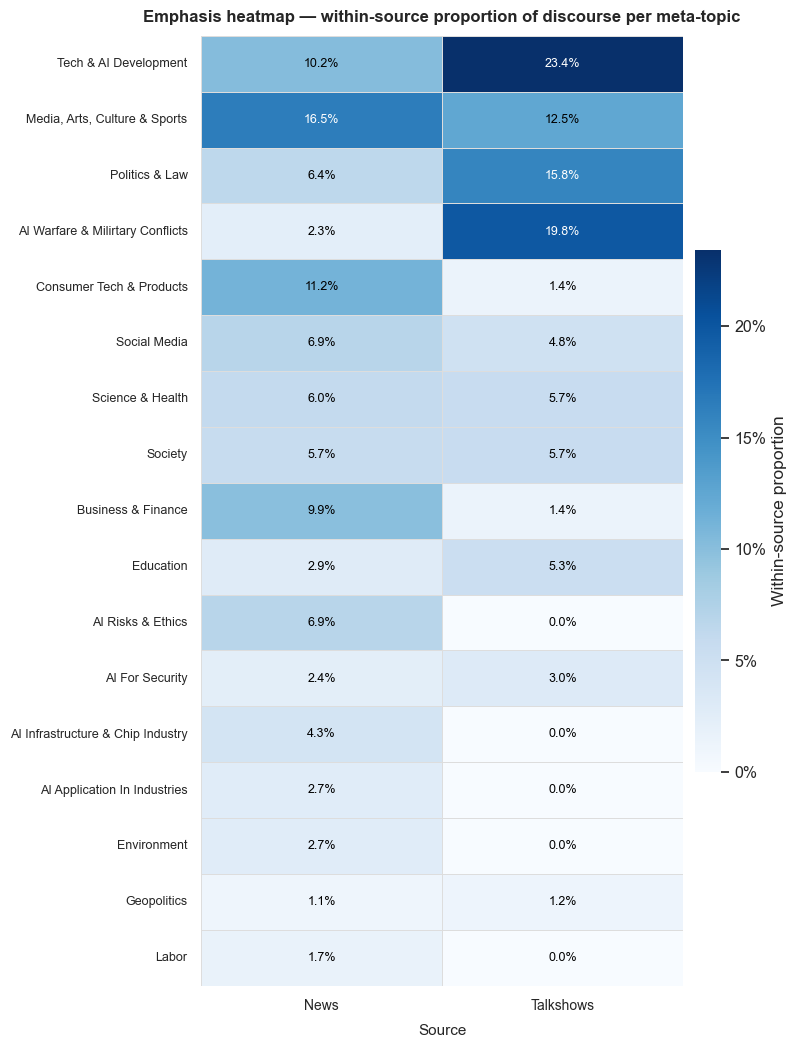

Saved emphasis_heatmap.png / .svg


In [6]:
def _auto_text_color(rgba):
    """Return 'white' or 'black' based on perceived luminance of a cell colour."""
    r, g, b, *_ = rgba
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if lum < 0.5 else "black"


def annotate_cells(ax, data, fmt_fn, cmap, norm):
    """
    Write formatted text in each heatmap cell with auto-contrasting colour.

    Parameters
    ----------
    ax     : the heatmap Axes
    data   : pd.DataFrame aligned with the heatmap (rows=y, cols=x)
    fmt_fn : callable(float) -> str
    cmap   : matplotlib colormap instance
    norm   : matplotlib Normalize (or TwoSlopeNorm) instance
    """
    vals = data.values.astype(float)
    for r, c in np.ndindex(data.shape):
        val  = vals[r, c]
        rgba = cmap(norm(val))
        ax.text(
            c + 0.5, r + 0.5, fmt_fn(val),
            ha="center", va="center",
            fontsize=ANNOT_FONTSIZE,
            color=_auto_text_color(rgba),
            fontweight="normal",
        )


def plot_emphasis_heatmap(prop, disp, sources):
    """
    Heatmap of within-source proportions.
    Rows = meta-topics (sorted by overall prevalence), columns = sources.
    Sequential single-hue colour scale; percentage annotated inside each cell.
    """
    n_rows, n_cols = prop.shape
    fig_w = max(6, n_cols * 2.8 + 2.5)
    fig_h = max(7, n_rows * 0.48 + 2.5)

    display_df = prop.rename(index=disp, columns=str.capitalize)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    vmax = prop.values.max()
    cmap = mcm.get_cmap(CMAP_EMPHASIS)
    norm = mcolors.Normalize(vmin=0, vmax=vmax)

    sns.heatmap(
        display_df, ax=ax,
        cmap=CMAP_EMPHASIS,
        vmin=0, vmax=vmax,
        annot=False,               # we annotate manually for colour control
        linewidths=0.6,
        linecolor="#dddddd",
        cbar_kws={"label": "Within-source proportion",
                  "shrink": 0.55, "pad": 0.02},
    )

    annotate_cells(ax, display_df, fmt_fn=lambda v: f"{v:.1%}", cmap=cmap, norm=norm)

    ax.set_title(
        "Emphasis heatmap — within-source proportion of discourse per meta-topic",
        fontsize=12, fontweight="bold", pad=10,
    )
    ax.set_xlabel("Source", fontsize=11, labelpad=8)
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=10, rotation=0)
    ax.tick_params(axis="y", labelsize=9,  rotation=0)

    # Format colorbar ticks as percentages
    cb = ax.collections[0].colorbar
    cb.ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:.0%}")
    )

    fig.tight_layout()
    return fig


fig_a = plot_emphasis_heatmap(prop_mat, disp, sources)
fig_a.savefig(OUT_DIR / "emphasis_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
fig_a.savefig(OUT_DIR / "emphasis_heatmap.svg", bbox_inches="tight")
plt.show()
print("Saved emphasis_heatmap.png / .svg")


## Step 3b — Deviation heatmap

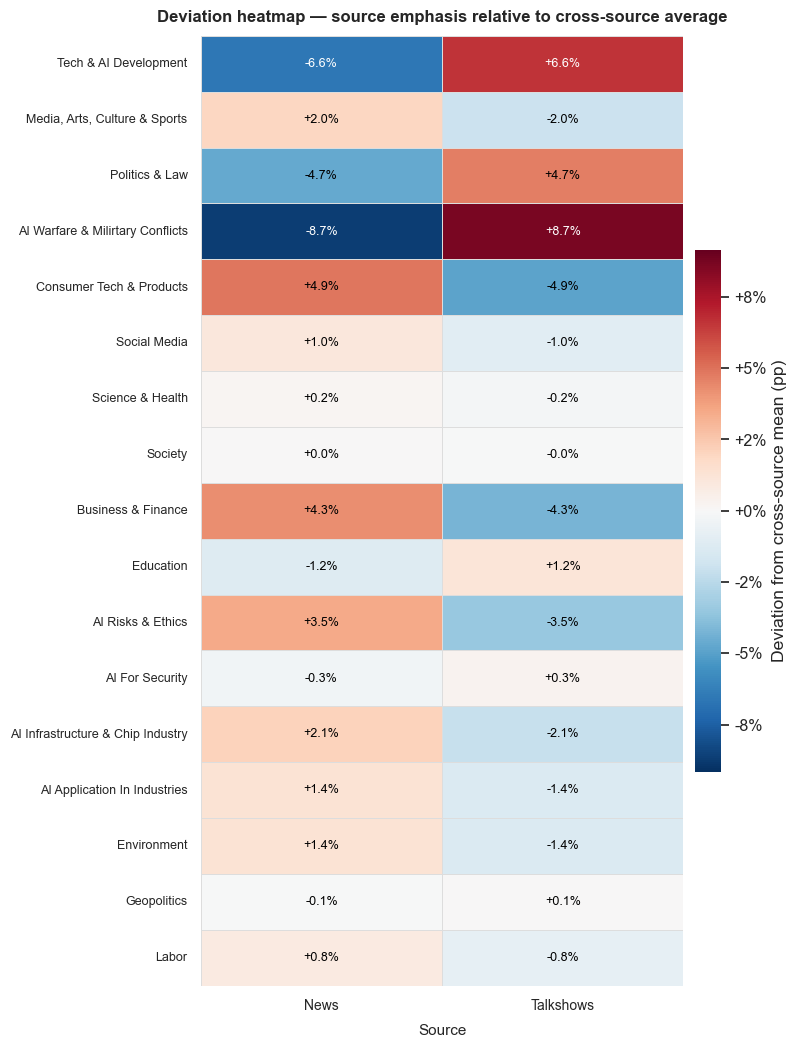

Saved deviation_heatmap.png / .svg


In [7]:
def plot_deviation_heatmap(dev, disp, sources):
    """
    Heatmap of deviations from the cross-source mean.
    Diverging colour scale centred at 0:
      red  = source over-emphasises this theme vs. field average
      blue = source under-emphasises

    Cells are annotated with the signed deviation in percentage points (pp).
    """
    n_rows, n_cols = dev.shape
    fig_w = max(6, n_cols * 2.8 + 2.5)
    fig_h = max(7, n_rows * 0.48 + 2.5)

    display_df = dev.rename(index=disp, columns=str.capitalize)

    abs_max = float(np.abs(dev.values).max()) * 1.05   # symmetric scale
    cmap    = mcm.get_cmap(CMAP_DEVIATION)
    norm    = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    sns.heatmap(
        display_df, ax=ax,
        cmap=CMAP_DEVIATION,
        vmin=-abs_max, vmax=abs_max,
        center=0,
        annot=False,
        linewidths=0.6,
        linecolor="#dddddd",
        cbar_kws={"label": "Deviation from cross-source mean (pp)",
                  "shrink": 0.55, "pad": 0.02},
    )

    annotate_cells(ax, display_df, fmt_fn=lambda v: f"{v:+.1%}", cmap=cmap, norm=norm)

    ax.set_title(
        "Deviation heatmap — source emphasis relative to cross-source average",
        fontsize=12, fontweight="bold", pad=10,
    )
    ax.set_xlabel("Source", fontsize=11, labelpad=8)
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=10, rotation=0)
    ax.tick_params(axis="y", labelsize=9,  rotation=0)

    cb = ax.collections[0].colorbar
    cb.ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:+.0%}")
    )

    fig.tight_layout()
    return fig


fig_b = plot_deviation_heatmap(dev_mat, disp, sources)
fig_b.savefig(OUT_DIR / "deviation_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
fig_b.savefig(OUT_DIR / "deviation_heatmap.svg", bbox_inches="tight")
plt.show()
print("Saved deviation_heatmap.png / .svg")


## Step 3c — Ternary plot *(requires exactly three sources)*

Each meta-topic becomes one point whose position in the triangle encodes how
its discourse is distributed across the three sources.  Corner proximity means
a theme is source-specific; centre proximity means it is shared equally.

This cell runs only when `len(sources) == 3`.


In [8]:
def _bary_to_cart(a, b, c):
    """Barycentric (a,b,c) with a+b+c=1 → Cartesian (x,y) in unit triangle."""
    x = b + c / 2
    y = c * np.sqrt(3) / 2
    return x, y


def _draw_triangle_grid(ax, levels=(0.2, 0.4, 0.6, 0.8), color="#cccccc", lw=0.6):
    """Draw the outer triangle and light internal grid lines."""    # Outer triangle
    verts = np.array([_bary_to_cart(*v) for v in [(1,0,0),(0,1,0),(0,0,1),(1,0,0)]])
    ax.plot(verts[:,0], verts[:,1], "k-", lw=1.5, zorder=3)

    for lv in levels:
        hi = 1 - lv
        # Lines parallel to each side
        for (a1,b1,c1), (a2,b2,c2) in [
            ((lv, hi, 0), (lv, 0, hi)),   # constant a
            ((0, lv, hi), (hi, lv, 0)),   # constant b
            ((0, hi, lv), (hi, 0, lv)),   # constant c
        ]:
            x1,y1 = _bary_to_cart(a1,b1,c1)
            x2,y2 = _bary_to_cart(a2,b2,c2)
            ax.plot([x1,x2],[y1,y2], color=color, lw=lw, zorder=1)


def plot_ternary(prop, disp, sources):
    """
    Ternary plot of meta-topic emphasis across three sources.
    Corner = source-specific theme; centre = equally shared.
    Marker size ∝ overall prevalence.
    """
    src_a, src_b, src_c = sources  # corners: bottom-left, bottom-right, top

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.set_aspect("equal")
    ax.axis("off")

    _draw_triangle_grid(ax)

    # Corner labels
    pad = 0.07
    for (x, y), label in [
        (_bary_to_cart(1,0,0), src_a.capitalize()),
        (_bary_to_cart(0,1,0), src_b.capitalize()),
        (_bary_to_cart(0,0,1), src_c.capitalize()),
    ]:
        dx = x - 0.5; dy = y - np.sqrt(3)/6
        ax.text(x + pad*dx, y + pad*dy, label,
                ha="center", va="center", fontsize=12, fontweight="bold")

    # Scale marker size by mean proportion (visual prevalence cue)
    mean_prop = prop.mean(axis=1)
    size_min, size_max = 60, 400

    # Colour by meta-topic index for visual distinction
    n = len(prop)
    cmap_pts = mcm.get_cmap("tab20", n)

    texts = []
    for i, meta in enumerate(prop.index):
        a = prop.loc[meta, src_a]
        b = prop.loc[meta, src_b]
        c = prop.loc[meta, src_c]
        s = a + b + c
        if s < 1e-9:
            continue
        a, b, c = a/s, b/s, c/s   # re-normalise so point lies inside triangle
        x, y = _bary_to_cart(a, b, c)

        sz = size_min + (size_max - size_min) * (mean_prop[meta] / mean_prop.max())
        ax.scatter(x, y, s=sz, color=cmap_pts(i), zorder=4, edgecolors="white", lw=0.8)
        texts.append((x, y, disp[meta]))

    # Annotate with meta-topic name (attempt simple offset to reduce overlap)
    for x, y, label in texts:
        ax.text(x, y + 0.025, label, ha="center", va="bottom",
                fontsize=6.5, zorder=5)

    # Axis labels inside edges (centred, rotated)
    for (xa,ya), (xb,yb), lbl in [
        (_bary_to_cart(1,0,0), _bary_to_cart(0,1,0), src_a.capitalize() + " ↔ " + src_b.capitalize()),
        (_bary_to_cart(0,1,0), _bary_to_cart(0,0,1), src_b.capitalize() + " ↔ " + src_c.capitalize()),
        (_bary_to_cart(1,0,0), _bary_to_cart(0,0,1), src_a.capitalize() + " ↔ " + src_c.capitalize()),
    ]:
        mx, my = (xa+xb)/2, (ya+yb)/2
        angle = np.degrees(np.arctan2(yb-ya, xb-xa))
        ax.text(mx, my - 0.05, lbl, ha="center", va="top", fontsize=8,
                rotation=angle, color="#555555")

    ax.set_title(
        "Ternary plot — meta-topic emphasis by source\n"
        "(corner = source-specific; centre = equally shared; size ∝ overall prevalence)",
        fontsize=11, fontweight="bold", pad=14,
    )
    ax.set_xlim(-0.12, 1.12)
    ax.set_ylim(-0.12, np.sqrt(3)/2 + 0.12)
    fig.tight_layout()
    return fig


if len(sources) == 3:
    fig_c = plot_ternary(prop_mat, disp, sources)
    fig_c.savefig(OUT_DIR / "ternary_plot.png", dpi=FIG_DPI, bbox_inches="tight")
    fig_c.savefig(OUT_DIR / "ternary_plot.svg", bbox_inches="tight")
    plt.show()
    print("Saved ternary_plot.png / .svg")
else:
    print(f"Ternary plot skipped — need exactly 3 sources, have {len(sources)}: {sources}")
    print("Add the 'kamer' path to SOURCE_FILES and rerun to generate the ternary plot.")


Ternary plot skipped — need exactly 3 sources, have 2: ['news', 'talkshows']
Add the 'kamer' path to SOURCE_FILES and rerun to generate the ternary plot.


## Step 4 — Concentration metrics and standout cells

In [10]:
def normalised_entropy(proportions):
    """
    Shannon entropy of a distribution, normalised to [0, 1].

    H_norm = 1  →  perfectly uniform (emphasis spread evenly across all themes)
    H_norm = 0  →  all discourse concentrated in one theme

    Uses the number of categories actually present in the matrix as the
    maximum-entropy baseline, so adding a source with a 0 in a meta-topic
    does not artificially inflate the denominator.
    """
    p   = np.asarray(proportions, dtype=float)
    p   = p[p > 0]           # avoid log(0)
    H   = scipy_entropy(p)   # natural-log Shannon entropy
    H_max = np.log(len(proportions))   # entropy of uniform over all categories
    return float(H / H_max) if H_max > 0 else 0.0


print("=" * 60)
print("CONCENTRATION — normalised entropy per source")
print("  (1 = evenly spread, 0 = all on one theme)")
print("-" * 60)
for src in sources:
    h = normalised_entropy(prop_mat[src].values)
    bar = "█" * int(round(h * 20))
    print(f"  {src:<12}  H_norm = {h:.3f}  {bar}")

# ── Standout cells ─────────────────────────────────────────────────────────────
stacked = (
    dev_mat.stack()
    .reset_index()
    .rename(columns={"level_0": "meta_topic", "level_1": "source", 0: "deviation"})
)
stacked["abs_dev"] = stacked["deviation"].abs()
top_n = min(10, len(stacked))
top   = stacked.nlargest(top_n, "abs_dev")

print()
print("=" * 60)
print(f"TOP {top_n} STANDOUT SOURCE–THEME PAIRS (by |deviation|)")
print("-" * 60)
for _, row in top.iterrows():
    direction = "over-emphasises" if row["deviation"] > 0 else "under-emphasises"
    print(
        f"  {row['source']:<12}  {direction:<16}  "
        f"'{disp[row['topic_meta']]}'"
        f"  ({row['deviation']:+.1%})"
    )

# ── Overall prevalence ranking ─────────────────────────────────────────────────
print()
print("=" * 60)
print("META-TOPIC PREVALENCE RANK (pooled, column-mean across sources)")
print("-" * 60)
for i, (meta, val) in enumerate(prop_mat.mean(axis=1).items(), 1):
    print(f"  {i:2d}. {disp[meta]:<40}  {val:.1%}")
print("=" * 60)


CONCENTRATION — normalised entropy per source
  (1 = evenly spread, 0 = all on one theme)
------------------------------------------------------------
  news          H_norm = 0.922  ██████████████████
  talkshows     H_norm = 0.748  ███████████████

TOP 10 STANDOUT SOURCE–THEME PAIRS (by |deviation|)
------------------------------------------------------------
  news          under-emphasises  'AI Warfare & Milirtary Conflicts'  (-8.7%)
  talkshows     over-emphasises   'AI Warfare & Milirtary Conflicts'  (+8.7%)
  news          under-emphasises  'Tech & AI Development'  (-6.6%)
  talkshows     over-emphasises   'Tech & AI Development'  (+6.6%)
  talkshows     under-emphasises  'Consumer Tech & Products'  (-4.9%)
  news          over-emphasises   'Consumer Tech & Products'  (+4.9%)
  talkshows     over-emphasises   'Politics & Law'  (+4.7%)
  news          under-emphasises  'Politics & Law'  (-4.7%)
  talkshows     under-emphasises  'Business & Finance'  (-4.3%)
  news          over-e